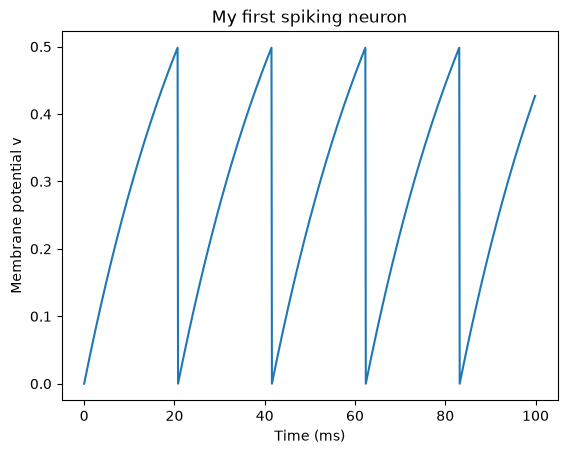

In [3]:
from brian2 import *

start_scope()
tau = 30*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''
G = NeuronGroup(1, eqs, threshold='v>0.5', reset='v=0', method='exact')
M = StateMonitor(G, 'v', record=True)
run(100*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('Membrane potential v')
title('My first spiking neuron')
show()

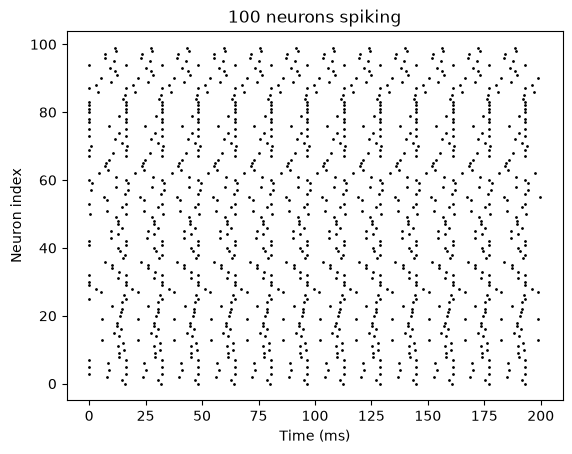

In [4]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

# Create 100 neurons instead of 1
G = NeuronGroup(100, eqs, threshold='v>0.8', reset='v=0', method='exact')

# Give each neuron a random starting voltage
G.v = 'rand()'

# Record spikes instead of voltage this time
spikemon = SpikeMonitor(G)

run(200*ms)

plot(spikemon.t/ms, spikemon.i, '.k', ms=2)
xlabel('Time (ms)')
ylabel('Neuron index')
title('100 neurons spiking')
show()

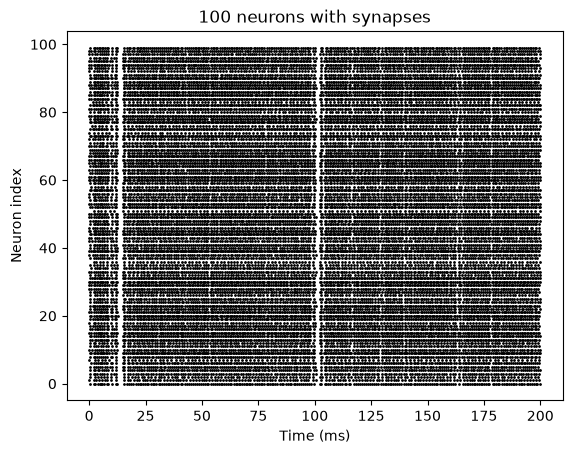

In [5]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(100, eqs, threshold='v>0.8', reset='v=0', method='exact')
G.v = 'rand()'

# Connect neurons to each other randomly
# When a neuron fires, it gives a small kick to connected neurons
S = Synapses(G, G, on_pre='v_post += 0.1')
S.connect(p=0.1)  # each neuron connects to 10% of others

spikemon = SpikeMonitor(G)
run(200*ms)

plot(spikemon.t/ms, spikemon.i, '.k', ms=2)
xlabel('Time (ms)')
ylabel('Neuron index')
title('100 neurons with synapses')
show()